########### Working with Actual Data from a Actual  CSV file


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
dataFromCsv = pd.read_csv('employees.csv')
#dataFromJson = pd.read_json('employees.json')

print(dataFromCsv.shape)
print(dataFromCsv.columns)
print(dataFromCsv.index)

import numpy as np

data_frame = pd.DataFrame(np.random.rand(5, 3), columns=['A', 'B', 'C'])
print(data_frame)

dictionaryPython = {'x':[1, 2, 3], 'y':[4, 5, 6], 'z':50}
data_frame = pd.DataFrame(dictionaryPython)
print(data_frame)

(1000, 8)
Index(['First Name', 'Gender', 'Start Date', 'Last Login Time', 'Salary',
       'Bonus %', 'Senior Management', 'Team'],
      dtype='str')
RangeIndex(start=0, stop=1000, step=1)
          A         B         C
0  0.214752  0.452465  0.909592
1  0.798248  0.827149  0.954236
2  0.006970  0.583206  0.025061
3  0.943832  0.078438  0.637809
4  0.202188  0.503279  0.230717
   x  y   z
0  1  4  50
1  2  5  50
2  3  6  50


In [ ]:
#CSV data manipulation
print("first 5 records : \n", dataFromCsv.head())
#print("last 5 records : \n", dataFromCsv.tail())

#print("first 4 records : \n", dataFromCsv.head().dropna())

#print("first 5 records : \n", dataFromCsv.head().fillna("TeamByPramod"))

#print("first 5 records : \n", dataFromCsv.head().replace("Male", "M"))

print("first 5 records : \n", dataFromCsv['Team'].str.upper().head())

first 5 records : 
   First Name  Gender  Start Date Last Login Time  Salary  Bonus %  \
0    Douglas    Male  08-06-1993        12:42 PM   97308    6.945   
1     Thomas    Male   3/31/1996         6:53 AM   61933    4.170   
2      Maria  Female   4/23/1993        11:17 AM  130590   11.858   
3      Jerry    Male  03-04-2005         1:00 PM  138705    9.340   
4      Larry    Male   1/24/1998         4:47 PM  101004    1.389   

  Senior Management             Team  
0              True        Marketing  
1              True              NaN  
2             False          Finance  
3              True          Finance  
4              True  Client Services  
first 5 records : 
 0          MARKETING
1                NaN
2            FINANCE
3            FINANCE
4    CLIENT SERVICES
Name: Team, dtype: str


In [23]:
###Data Aggregation and Grouping
print(dataFromCsv.groupby('Team')['Salary'].mean())

#print(dataFromCsv.groupby('Team')['Salary'].max())

#print(dataFromCsv.groupby('Team')['Salary'].min())

#Sprint(dataFromCsv.pivot_table(values='Salary', index='Team', aggfunc='mean'))



Team
Business Development    91866.316832
Client Services         88224.424528
Distribution            88500.466667
Engineering             94269.195652
Finance                 92219.480392
Human Resources         90944.527473
Legal                   89303.613636
Marketing               90435.591837
Product                 88665.505263
Sales                   92173.436170
Name: Salary, dtype: float64


In [25]:
## Merging Joining and Concatenating DataFrames
data1 = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['Alice', 'Bob', 'Charlie']})
print(data1)
data2 = pd.DataFrame({'ID': [2, 3, 4], 'Age': [25, 30, 35]})    
print(data2)   
print("going to Merge data with inner join :> ") 
merged_data = pd.merge(data1, data2, on='ID', how='inner')
print(merged_data)
print("going to concatenate data1 with data2 :> ") 
concatenated_data = pd.concat([data1, data2], ignore_index=True)
print(concatenated_data)

   ID     Name
0   1    Alice
1   2      Bob
2   3  Charlie
   ID  Age
0   2   25
1   3   30
2   4   35
going to Merge data with inner join :> 
   ID     Name  Age
0   2      Bob   25
1   3  Charlie   30
going to concatenate data1 with data2 :> 
   ID     Name   Age
0   1    Alice   NaN
1   2      Bob   NaN
2   3  Charlie   NaN
3   2      NaN  25.0
4   3      NaN  30.0
5   4      NaN  35.0


### Working with time series data


In [32]:
#Working with time series data
date_range = pd.date_range(start='2023-01-01', end='2023-01-10')
print(date_range)

print("Original data :> ")
print(date_range)


#TimeSeriesSalesData = pd.read_csv('sales_time_series_data.csv')
#print("Original Time Series Sales Data :> ")

# Load the data
df = pd.read_csv('sales_time_series_data.csv')

# IMPORTANT: Convert string column to Datetime objects
df['SaleDateTime'] = pd.to_datetime(df['SaleDateTime'])

# Set the date as the index (crucial for time series)
df.set_index('SaleDateTime', inplace=True)


DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10'],
              dtype='datetime64[us]', freq='D')
Original data :> 
DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10'],
              dtype='datetime64[us]', freq='D')


In [35]:
#In Pandas, grouping by time is called Resampling. It is much more efficient than standard.
df.resample('D')['ProductPrice'].sum() # Resample by day and sum the product prices
df.resample('W')['ProductPrice'].sum() # Resample by week and sum the product prices
# Group by Month and sum the prices
monthly_sales = df.resample('ME')['ProductPrice'].sum()
print("Monthly Sales :> ")
print(monthly_sales)

Monthly Sales :> 
SaleDateTime
2024-01-31    20500.0
2024-02-29    26365.0
2024-03-31    27470.0
2024-04-30    28600.0
2024-05-31    28995.0
2024-06-30    29410.0
2024-07-31    25525.0
2024-08-31    24245.0
2024-09-30    29910.0
2024-10-31    34480.0
2024-11-30    26455.0
2024-12-31    18995.0
2025-01-31    29680.0
2025-02-28    20990.0
2025-03-31    17660.0
2025-04-30    30000.0
2025-05-31    27185.0
2025-06-30    20870.0
Freq: ME, Name: ProductPrice, dtype: float64


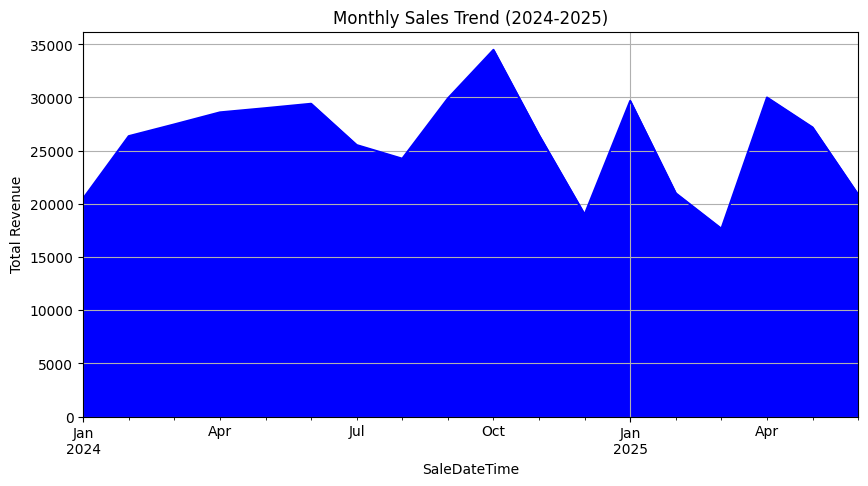

In [46]:
# Plot the results
#monthly_sales.plot(kind='line', marker='o', figsize=(10, 5), color='blue') # line plot with markers
#monthly_sales.plot(kind='bar', figsize=(10, 5), color='blue')
#monthly_sales.plot(kind='barh', figsize=(10, 5), color='blue') # horizontal bar chart = barh
#monthly_sales.plot(kind='pie', figsize=(10, 5), color='blue') # circular pie chart = pie
monthly_sales.plot(kind='area', figsize=(10, 5), color='blue') # Filled line plot = area
plt.title('Monthly Sales Trend (2024-2025)')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()